# AI 211 - Machine Exercise 1
## Problem 2: Classifying Breast Tumors

**Instructor:** Prof. Karl Ezra Pilario, Ph.D.  
**Due Date:** 11:59 PM, September 15, 2026  
**Semester:** 1st Semester, AY 2026-2027  

**Authors:** Adriane Jone A. Abunda | Ejcurl B. Delarmente

### Problem
Reference: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29 

Download the Wisconsin Breast Cancer dataset. The dataset contains 569 instances of breast tumors 
with 30 attributes. The goal is make a classifer for the tumor status. 

- a. [20 pts] Split the samples into 70% Training and 30% Testing at random. Make sure to use 
“stratify=y” in the test_train_split function. Build a pipeline using the Standard scaler and logistic 
regression. Use the default penalty settings of Logistic Regression. After fitting the data, what is 
the model’s training and testing accuracy? Which features are most important? 
- b. [20 pts] From your answer in item (a), generate a confusion matrix, then calculate the other 
metrics: F1-score, Precision, Recall, and False alarm rate. Finally, plot the ROC curve and report 
the AUC. For this item, make a result for both the training and testing data, separately. 

Based on your results for this Problem, what insights did you gain?

In [1]:
# Import libraries and pacakges
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 23

In [2]:
# Load the dataset
columns = [
    "ID", "Diagnosis", "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1",
    "concave_points1", "symmetry1", "fractal_dimension1", "radius2", "texture2", "perimeter2", "area2", "smoothness2",
    "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2", "radius3", "texture3",
    "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3"
]
data = pd.read_csv("wdbc.data", header=None, names=columns)
data.head(5)

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# EDA
## Dataset Preview
Size, Dtypes, missing values, duplicates, etc.

In [3]:
# Drop the ID column as it has no predictive value
data = data.drop("ID", axis=1)  

In [5]:
data.shape

(569, 31)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Diagnosis           569 non-null    str    
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactness2       

In [7]:
data.duplicated().sum()

np.int64(0)

## Statistical Overview

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Diagnosis class distribution

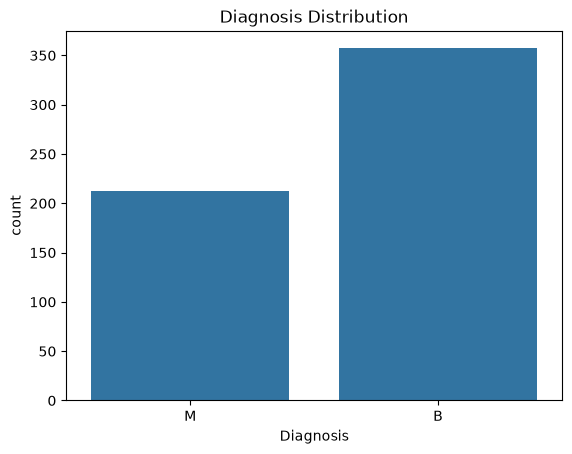

In [9]:
data['Diagnosis'].value_counts()
sns.countplot(data=data, x='Diagnosis')
plt.title('Diagnosis Distribution')
plt.show()

## Correlation Analysis (Relationship between features to the Diagnosis)

concave_points3       0.793566
perimeter3            0.782914
concave_points1       0.776614
radius3               0.776454
perimeter1            0.742636
area3                 0.733825
radius1               0.730029
area1                 0.708984
concavity1            0.696360
concavity3            0.659610
compactness1          0.596534
compactness3          0.590998
radius2               0.567134
perimeter2            0.556141
area2                 0.548236
texture3              0.456903
smoothness3           0.421465
symmetry3             0.416294
texture1              0.415185
concave_points2       0.408042
smoothness1           0.358560
symmetry1             0.330499
fractal_dimension3    0.323872
compactness2          0.292999
concavity2            0.253730
fractal_dimension2    0.077972
symmetry2            -0.006522
texture2             -0.008303
fractal_dimension1   -0.012838
smoothness2          -0.067016
Name: Diagnosis_num, dtype: float64


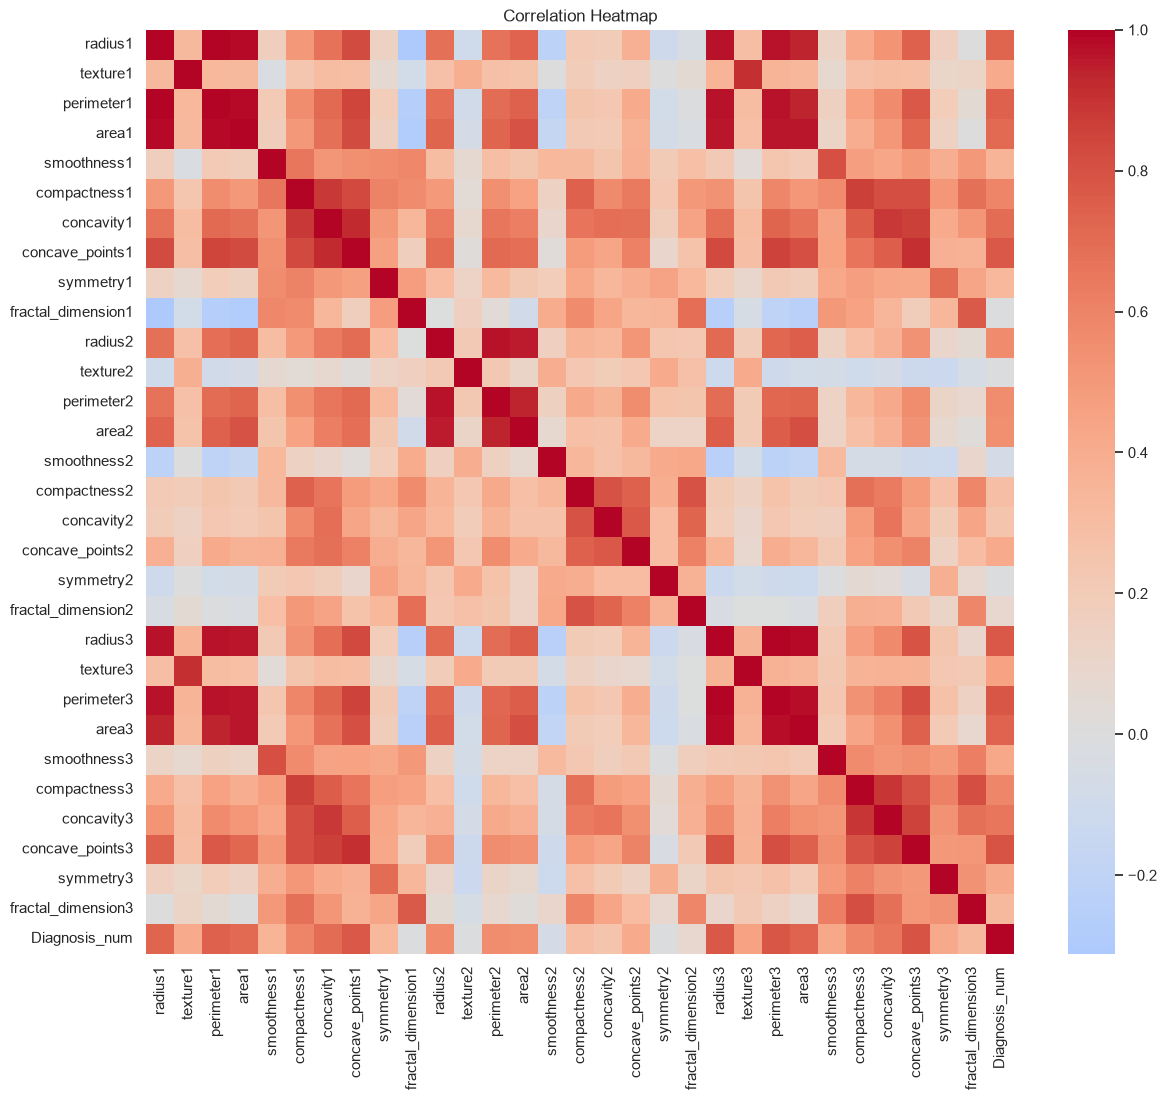

In [10]:
temp_target = data['Diagnosis'].map({'M': 1, 'B': 0})
corr_matrix = data.assign(Diagnosis_num=temp_target).drop(columns=['Diagnosis']).corr()

corr_with_target = corr_matrix['Diagnosis_num'].drop('Diagnosis_num').sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(14, 12))
sns.set(style="whitegrid")  
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Machine Learning Model Development

Feature, Model Selection, Preprocessing, and Training

In [11]:
# Feature selection and preprocessing
data['Diagnosis'] = data['Diagnosis'].map({'M': 1, 'B': 0})

X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

print(f"Predictors columns: {X.columns}")
print(f"Target columns: {y.unique()}")

Predictors columns: Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='str')
Target columns: [1 0]
